<a href="https://colab.research.google.com/github/magenta/mt3/blob/main/mt3/colab/music_transcription_with_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Music Transcription with Transformers

This notebook is an interactive demo of a few [music transcription models](g.co/magenta/mt3) created by Google's [Magenta](g.co/magenta) team.  You can upload audio and have one of our models automatically transcribe it.

<img src="https://magenta.tensorflow.org/assets/transcription-with-transformers/architecture_diagram.png" alt="Transformer-based transcription architecture">

The notebook supports two pre-trained models:
1. the piano transcription model from [our ISMIR 2021 paper](https://archives.ismir.net/ismir2021/paper/000030.pdf)
1. the multi-instrument transcription model from [our ICLR 2022 paper](https://openreview.net/pdf?id=iMSjopcOn0p)

**Caveat**: neither model is trained on singing.  If you upload audio with vocals, you will likely get weird results.  Multi-instrument transcription is still not a completely-solved problem and so you may get weird results regardless.

In any case, we hope you have fun transcribing!  Feel free to tweet any interesting output at [@GoogleMagenta](https://twitter.com/googlemagenta)...

### Instructions for running:

* Make sure to use a GPU runtime, click:  __Runtime >> Change Runtime Type >> GPU__
* Press ▶️ on the left of each cell to execute the cell
* In the __Load Model__ cell, choose either `ismir2021` for piano transcription or `mt3` for multi-instrument transcription
* In the __Upload Audio__ cell, choose an MP3 or WAV file from your computer when prompted
* Transcribe the audio using the __Transcribe Audio__ cell (it may take a few minutes depending on the length of the audio)

---

This notebook sends basic usage data to Google Analytics.  For more information, see [Google's privacy policy](https://policies.google.com/privacy).

In [1]:
!python --version

Python 3.9.19


In [2]:

import torch
import torch.nn.functional as F
from transformers import AutoFeatureExtractor, WhisperModel, WhisperConfig, WhisperProcessor
import transformers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'{device}, {torch.__version__=}, {torch.cuda.is_available()=}, {torch.version.cuda=}, {transformers.__version__=}')

# assert device is cuda or print error that cuda is needed
assert device.type == 'cuda', 'CUDA is not available'

ModuleNotFoundError: No module named 'torch'

In [3]:
# Copyright 2021 Google LLC. All Rights Reserved.

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

#     http://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================

#@title Setup Environment
#@markdown Install MT3 and its dependencies (may take a few minutes).

# !apt-get update -qq && apt-get install -qq libfluidsynth3 build-essential libasound2-dev libjack-dev

# # install mt3
# !git clone --branch=main https://github.com/magenta/mt3
# !mv mt3 mt3_tmp; mv mt3_tmp/* .; rm -r mt3_tmp
# !python3 -m pip install jax[cuda11_local] nest-asyncio pyfluidsynth==1.3.0 -e . -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

# copy checkpoints
# !gsutil -q -m cp -r gs://mt3/checkpoints .

# copy soundfont (originally from https://sites.google.com/site/soundfonts4u)
# !gsutil -q -m cp gs://magentadata/soundfonts/SGM-v2.01-Sal-Guit-Bass-V1.3.sf2 .

import json
import IPython

# The below functions (load_gtag and log_event) handle Google Analytics event
# logging. The logging is anonymous and stores only very basic statistics of the
# audio and transcription e.g. length of audio, number of transcribed notes.

def load_gtag():
  """Loads gtag.js."""
  # Note: gtag.js MUST be loaded in the same cell execution as the one doing
  # synthesis. It does NOT persist across cell executions!
  html_code = '''
<!-- Global site tag (gtag.js) - Google Analytics -->
<script async src="https://www.googletagmanager.com/gtag/js?id=G-4P250YRJ08"></script>
<script>
  window.dataLayer = window.dataLayer || [];
  function gtag(){dataLayer.push(arguments);}
  gtag('js', new Date());
  gtag('config', 'G-4P250YRJ08',
       {'referrer': document.referrer.split('?')[0],
        'anonymize_ip': true,
        'page_title': '',
        'page_referrer': '',
        'cookie_prefix': 'magenta',
        'cookie_domain': 'auto',
        'cookie_expires': 0,
        'cookie_flags': 'SameSite=None;Secure'});
</script>
'''
  IPython.display.display(IPython.display.HTML(html_code))

def log_event(event_name, event_details):
  """Log event with name and details dictionary."""
  details_json = json.dumps(event_details)
  js_string = "gtag('event', '%s', %s);" % (event_name, details_json)
  IPython.display.display(IPython.display.Javascript(js_string))

load_gtag()
log_event('setupComplete', {})

<IPython.core.display.Javascript object>

In [38]:
#@title Imports and Definitions

import functools
import os

import numpy as np
import tensorflow.compat.v2 as tf

import functools
import gin
import jax
import librosa
import note_seq
import seqio
import t5
import t5x

from mt3 import metrics_utils
from mt3 import models
from mt3 import network
from mt3 import note_sequences
from mt3 import preprocessors
from mt3 import spectrograms
from mt3 import vocabularies

# from google.colab import files

import nest_asyncio
nest_asyncio.apply()

SAMPLE_RATE = 16000
SF2_PATH = 'musictranscription/SGM-v2.01-Sal-Guit-Bass-V1.3.sf2'

# def upload_audio(sample_rate):
#   data = list(files.upload().values())
#   return

#   if len(data) > 1:
#     print('Multiple files uploaded; using only one.')
#   return note_seq.audio_io.wav_data_to_samples_librosa(
#     data[0], sample_rate=sample_rate)



class InferenceModel(object):
  """Wrapper of T5X model for music transcription."""

  def __init__(self, checkpoint_path, model_type='mt3'):

    # Model Constants.
    if model_type == 'ismir2021':
      num_velocity_bins = 127
      self.encoding_spec = note_sequences.NoteEncodingSpec
      self.inputs_length = 512
    elif model_type == 'mt3':
      num_velocity_bins = 1
      self.encoding_spec = note_sequences.NoteEncodingWithTiesSpec
      self.inputs_length = 256  # Increased from 256
    else:
      raise ValueError('unknown model_type: %s' % model_type)

    gin_files = ['mt3/gin/model.gin',
                 f'mt3/gin/{model_type}.gin']

    self.batch_size = 8
    self.outputs_length = 1024  # Increased from 1024
    self.sequence_length = {'inputs': self.inputs_length,
                            'targets': self.outputs_length}

    self.partitioner = t5x.partitioning.PjitPartitioner(
        num_partitions=1)

    # Build Codecs and Vocabularies.
    self.spectrogram_config = spectrograms.SpectrogramConfig()
    self.codec = vocabularies.build_codec(
        vocab_config=vocabularies.VocabularyConfig(
            num_velocity_bins=num_velocity_bins))
    self.vocabulary = vocabularies.vocabulary_from_codec(self.codec)
    self.output_features = {
        'inputs': seqio.ContinuousFeature(dtype=tf.float32, rank=2),
        'targets': seqio.Feature(vocabulary=self.vocabulary),
    }

    # Create a T5X model.
    self._parse_gin(gin_files)
    self.model = self._load_model()

    # Restore from checkpoint.
    self.restore_from_checkpoint(checkpoint_path)

  @property
  def input_shapes(self):
    return {
          'encoder_input_tokens': (self.batch_size, self.inputs_length),
          'decoder_input_tokens': (self.batch_size, self.outputs_length)
    }

  def _parse_gin(self, gin_files):
    """Parse gin files used to train the model."""
    gin_bindings = [
        'from __gin__ import dynamic_registration',
        'from mt3 import vocabularies',
        'VOCAB_CONFIG=@vocabularies.VocabularyConfig()',
        'vocabularies.VocabularyConfig.num_velocity_bins=%NUM_VELOCITY_BINS'
    ]
    with gin.unlock_config():
      gin.parse_config_files_and_bindings(
          gin_files, gin_bindings, finalize_config=False)

  def _load_model(self):
    """Load up a T5X `Model` after parsing training gin config."""
    model_config = gin.get_configurable(network.T5Config)()
    module = network.Transformer(config=model_config)
    return models.ContinuousInputsEncoderDecoderModel(
        module=module,
        input_vocabulary=self.output_features['inputs'].vocabulary,
        output_vocabulary=self.output_features['targets'].vocabulary,
        optimizer_def=t5x.adafactor.Adafactor(decay_rate=0.8, step_offset=0),
        input_depth=spectrograms.input_depth(self.spectrogram_config))


  def restore_from_checkpoint(self, checkpoint_path):
    """Restore training state from checkpoint, resets self._predict_fn()."""
    train_state_initializer = t5x.utils.TrainStateInitializer(
      optimizer_def=self.model.optimizer_def,
      init_fn=self.model.get_initial_variables,
      input_shapes=self.input_shapes,
      partitioner=self.partitioner)

    restore_checkpoint_cfg = t5x.utils.RestoreCheckpointConfig(
        path=checkpoint_path, mode='specific', dtype='float32')

    train_state_axes = train_state_initializer.train_state_axes
    self._predict_fn = self._get_predict_fn(train_state_axes)
    self._train_state = train_state_initializer.from_checkpoint_or_scratch(
        [restore_checkpoint_cfg], init_rng=jax.random.PRNGKey(0))

  @functools.lru_cache()
  def _get_predict_fn(self, train_state_axes):
    """Generate a partitioned prediction function for decoding."""
    def partial_predict_fn(params, batch, decode_rng):
      return self.model.predict_batch_with_aux(
          params, batch, decoder_params={'decode_rng': None})
    return self.partitioner.partition(
        partial_predict_fn,
        in_axis_resources=(
            train_state_axes.params,
            t5x.partitioning.PartitionSpec('data',), None),
        out_axis_resources=t5x.partitioning.PartitionSpec('data',)
    )

  def predict_tokens(self, batch, seed=0):
    """Predict tokens from preprocessed dataset batch."""
    prediction, _ = self._predict_fn(
        self._train_state.params, batch, jax.random.PRNGKey(seed))
    return self.vocabulary.decode_tf(prediction).numpy()

  def __call__(self, audio):
    """Infer note sequence from audio samples.

    Args:
      audio: 1-d numpy array of audio samples (16kHz) for a single example.

    Returns:
      A note_sequence of the transcribed audio.
    """
    ds = self.audio_to_dataset(audio)
    ds = self.preprocess(ds)

    model_ds = self.model.FEATURE_CONVERTER_CLS(pack=False)(
        ds, task_feature_lengths=self.sequence_length)
    model_ds = model_ds.batch(self.batch_size)

    # inferences = (tokens for batch in model_ds.as_numpy_iterator()
    #               for tokens in self.predict_tokens(batch))

    def process_inferences(model_ds):
      for batch in model_ds.as_numpy_iterator():
          tokens_batch = self.predict_tokens(batch)
          for tokens in tokens_batch:
              yield tokens

    inferences = process_inferences(model_ds)


    predictions = []
    for example, tokens in zip(ds.as_numpy_iterator(), inferences):
      predictions.append(self.postprocess(tokens, example))

    result = metrics_utils.event_predictions_to_ns(
        predictions, codec=self.codec, encoding_spec=self.encoding_spec)
    return result['est_ns']

  def audio_to_dataset(self, audio):
    """Create a TF Dataset of spectrograms from input audio."""
    frames, frame_times = self._audio_to_frames(audio)
    return tf.data.Dataset.from_tensors({
        'inputs': frames,
        'input_times': frame_times,
    })

  def _audio_to_frames(self, audio):
    """Compute spectrogram frames from audio."""
    frame_size = self.spectrogram_config.hop_width
    padding = [0, frame_size - len(audio) % frame_size]
    audio = np.pad(audio, padding, mode='constant')
    frames = spectrograms.split_audio(audio, self.spectrogram_config)
    num_frames = len(audio) // frame_size
    times = np.arange(num_frames) / self.spectrogram_config.frames_per_second
    return frames, times

  def preprocess(self, ds):
    pp_chain = [
        functools.partial(
            t5.data.preprocessors.split_tokens_to_inputs_length,
            sequence_length=self.sequence_length,
            output_features=self.output_features,
            feature_key='inputs',
            additional_feature_keys=['input_times']),
        # Cache occurs here during training.
        preprocessors.add_dummy_targets,
        functools.partial(
            preprocessors.compute_spectrograms,
            spectrogram_config=self.spectrogram_config)
    ]
    for pp in pp_chain:
      ds = pp(ds)
    return ds

  def postprocess(self, tokens, example):
    tokens = self._trim_eos(tokens)
    start_time = example['input_times'][0]
    # Round down to nearest symbolic token step.
    start_time -= start_time % (1 / self.codec.steps_per_second)
    return {
        'est_tokens': tokens,
        'start_time': start_time,
        # Internal MT3 code expects raw inputs, not used here.
        'raw_inputs': []
    }

  @staticmethod
  def _trim_eos(tokens):
    tokens = np.array(tokens, np.int32)
    if vocabularies.DECODED_EOS_ID in tokens:
      tokens = tokens[:np.argmax(tokens == vocabularies.DECODED_EOS_ID)]
    return tokens



In [39]:
#@title Load Model
#@markdown The `ismir2021` model transcribes piano only, with note velocities.
#@markdown The `mt3` model transcribes multiple simultaneous instruments,
#@markdown but without velocities.

MODEL = "mt3" #@param["ismir2021", "mt3"]

mt3_path = 'musictranscription/checkpoints'

checkpoint_path = f'{mt3_path}/{MODEL}/'

# load_gtag()
print(checkpoint_path)
# log_event('loadModelStart', {'event_category': MODEL})
inference_model = InferenceModel(checkpoint_path, MODEL)
# log_event('loadModelComplete', {'event_category': MODEL})


musictranscription/checkpoints/mt3/


In [49]:
#@title Upload Audio

from pydub import AudioSegment

def split_mp3(file_path, chunk_length_ms=10000, num_chunks=5):
    output_dir = 'content'
    # Load the mp3 file
    audio = AudioSegment.from_mp3(file_path)
    split_filenames = []

    # Length of the audio in milliseconds
    length_ms = len(audio)

    # Start and end points for slicing
    start_ms = 0
    end_ms = chunk_length_ms

    file_counter = 0

    # Splitting the audio
    chunks = []
    while start_ms < length_ms and len(chunks) < num_chunks:
        # Extract the chunk
        chunk = audio[start_ms:end_ms]

        # Save the chunk as a separate file
        chunk_name = f"{output_dir}/{file_counter}.mp3"
        chunk.export(chunk_name, format="mp3")
        split_filenames.append(chunk_name)

        # Append the chunk to the list
        chunks.append(chunk)

        # Move to the next chunk
        start_ms = end_ms
        end_ms += chunk_length_ms
        file_counter += 1

    return chunks, split_filenames


# TODO @sammy: use a fixed local path from host to avoid constant copy/paste
audio_file_paths = {
    'short': 'why-georgia-30.mp3',
    'long': '../../dataset/john-mayer/30_Why_Georgia.mp3'
}

audio_file_path = audio_file_paths['long']

# mp3 is split into N segments of audio chunk length.
# To transcribe entire mp3, num_transcription_segments = len(audio) / audio_chunk_length
# To transcribe the first 2 seconds of an mp3, set NUM_TRANSCRIPTION_SEGMENTS to 1 assuming length is 2 seconds
NUM_TRANSCRIPTION_SEGMENTS = 1
AUDIO_CHUNK_LENGTH = 30000
split_audio, split_audio_filenames = split_mp3(audio_file_path, AUDIO_CHUNK_LENGTH, NUM_TRANSCRIPTION_SEGMENTS)

# audio = upload_audio(sample_rate=SAMPLE_RATE)
# log_event('uploadAudioComplete', {'value': round(len(audio) / SAMPLE_RATE)})

# note_seq.notebook_utils.colab_play(audio, sample_rate=SAMPLE_RATE)

In [50]:
#@title Transcribe Audio
#@markdown This may take a few minutes depending on the length of the audio file
#@markdown you uploaded.


def transcribe_audio(audio, play_audio=False):
  est_ns = inference_model(audio)

  if play_audio:
    note_seq.play_sequence(est_ns, synth=note_seq.fluidsynth,
                           sample_rate=SAMPLE_RATE, sf2_path=SF2_PATH)
  # note_seq.plot_sequence(est_ns)
  return est_ns

In [51]:
#@title Download MIDI Transcription

def download_midi(est_ns, download_path='transcription.midi'):
  note_seq.sequence_proto_to_midi_file(est_ns, download_path)
  # files.download('/tmp/transcribed.mid')

In [52]:
split_audio_filenames

['content/0.mp3']

In [53]:
def transcribe_and_download():
  download_filenames = []

  for (audio_chunk, audio_filename) in zip(split_audio, split_audio_filenames):
    audio, sr = librosa.load(audio_filename, sr=SAMPLE_RATE, mono=True)
    est_ns = transcribe_audio(audio)
    download_filename = audio_filename.rsplit('.', 1)[0] + '.midi'
    download_midi(est_ns, download_filename)
    download_filenames.append(download_filename)

  return download_filenames

download_filenames = transcribe_and_download()

2024-05-26 21:56:30.950739: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [54]:
download_filenames

['content/0.midi']

In [55]:
midi_files = download_filenames

In [56]:
midi_files

['content/0.midi']

In [57]:
# play the first midi file
note_seq.play_sequence(note_seq.midi_file_to_note_sequence(midi_files[0]), synth=note_seq.fluidsynth, sample_rate=SAMPLE_RATE, sf2_path=SF2_PATH)

# combine all the downloaded midi files into one

In [14]:
# !pip install mido

In [15]:
import matplotlib.pyplot as plt
from mido import MidiFile, MidiTrack

In [16]:
first_midi = MidiFile(download_filenames[0])

In [17]:
second_midi = MidiFile(download_filenames[1])

Cumulative time: 1229 for track 0
Cumulative time: 1229 for track 1
Cumulative time: 1224 for track 2


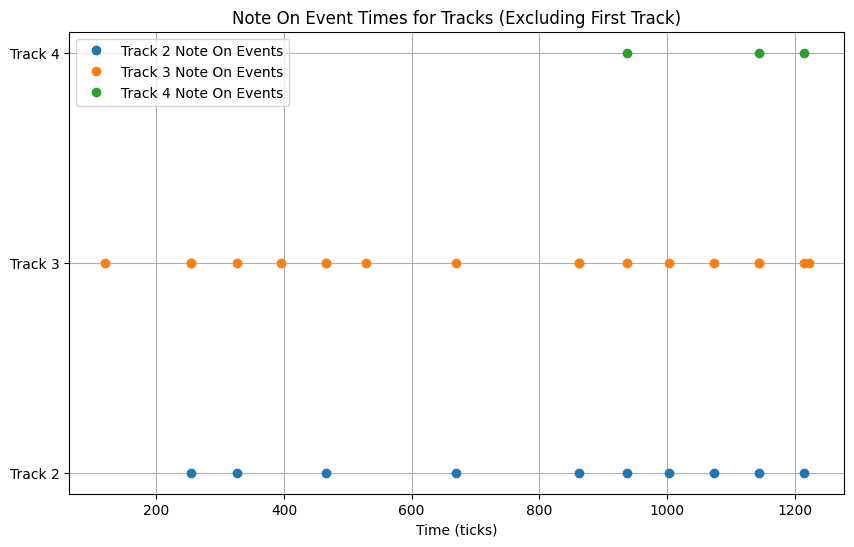

In [18]:
def plot_note_on_times(midi_file_path):
    midi_file = MidiFile(midi_file_path)

    # Initialize lists to store note_on times for each track
    note_on_times = []

    for i, track in enumerate(midi_file.tracks[1:]):  # Skip the first track
        cumulative_time = 0
        track_times = []

        for msg in track:
            cumulative_time += msg.time
            if msg.type == 'note_on' and msg.velocity > 0:  # Check for actual note_on event
                track_times.append(cumulative_time)

        print(f"Cumulative time: {cumulative_time} for track {i}")
        note_on_times.append(track_times)

    # Plotting
    plt.figure(figsize=(10, 6))
    for i, times in enumerate(note_on_times):
        plt.plot(times, [i+1] * len(times), 'o', label=f'Track {i+2} Note On Events')  # i+2 because we skipped the first track

    plt.yticks(range(1, len(note_on_times) + 1), [f'Track {i+2}' for i in range(len(note_on_times))])
    plt.xlabel('Time (ticks)')
    plt.title('Note On Event Times for Tracks (Excluding First Track)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Replace with the path to your MIDI file
midi_file_path = download_filenames[0]
plot_note_on_times(midi_file_path)


In [19]:
def copy_acoustic_guitar_events(midi_files, output_file):
    # Create a new MIDI file for the output
    output_midi = MidiFile()

    metadata_track = MidiTrack()
    acoustic_track = MidiTrack()
    output_midi.tracks.append(metadata_track)

    end_of_track_msg = None

    # Process the first MIDI file to keep its tempo and time signature
    first_midi = MidiFile(midi_files[0])
    for msg in first_midi.tracks[0]:
        if msg.is_meta:
            metadata_track.append(msg.copy())

    # set the ticks per beat in output midi to be the same as first midi
    output_midi.ticks_per_beat = first_midi.ticks_per_beat

    for file_path in midi_files:
        midi_file = MidiFile(file_path)

        for track_idx, track in enumerate(midi_file.tracks):
            # Flag to track whether we are currently copying events
            copy_events = False

            for msg_idx, msg in enumerate(track):
                # Check for program change messages
                if msg.type == 'program_change' and msg.program == 24:
                    # Start copying when program 24 (acoustic guitar) is encountered
                    copy_events = True
                elif msg.type == 'program_change' and msg.program != 24:
                    # Stop copying if a different program is set
                    copy_events = False

                if copy_events:
                  # Check if acoustic track is empty
                  if len(acoustic_track) == 0 and msg.type == 'program_change':
                    acoustic_track.append(msg.copy())
                    continue

                  # Add end of track message if last message
                  if msg_idx == len(track) - 1 and msg.type == 'end_of_track':
                    end_of_track_msg = msg.copy()

                  # Ignore end of track messages and program change events
                  if msg.type == 'end_of_track' or msg.type == 'program_change':
                      continue

                  # Copy the event to the new track
                  acoustic_track.append(msg.copy())

    # Add the end of track message to the acoustic track
    if end_of_track_msg is not None:
        acoustic_track.append(end_of_track_msg)

    output_midi.tracks.append(acoustic_track)
    # Save the output MIDI file
    output_midi.save(output_file)
    return output_midi



# # Copy acoustic guitar events to a new MIDI file
# output_file = 'acoustic_guitar_only.midi'
# acoustic_guitar_midi = copy_acoustic_guitar_events(midi_files, output_file)

# print(f"Acoustic guitar events copied to '{output_file}'")




In [20]:
def delete_midi_and_mp3s():
  # delete all the midi and mp3 files stored in /content such as /content/0.mp3, /content/0.midi, etc..
  # content_pathname = 'musictranscription/content'     #'content' 
  content_pathname = 'content'
  for file in os.listdir(content_pathname):
    print(file)
    # do not delete 3_why_georgia or why_georgia-30.mp3
    if file.endswith('.mp3'):
      os.remove(os.path.join(content_pathname, file))
    elif file.endswith('.midi'):
      os.remove(os.path.join(content_pathname, file))
    elif file.endswith('.mid'):
      os.remove(os.path.join(content_pathname, file))

# delete_midi_and_mp3s()

In [21]:
from mido import merge_tracks

In [22]:
def stitch_midi_files(midi_files):
    # Initialize a new MIDI file
    stitched_midi = MidiFile()
    first_file = True
    metadata_track = MidiTrack()
    stitched_midi.tracks.append(metadata_track)
    end_of_track_msg = None

    for file_path in midi_files:
        midi = MidiFile(file_path)

        for i, track in enumerate(midi.tracks):
            # If it's the first file, add new tracks to the stitched MIDI
            if len(stitched_midi.tracks) <= i:
                stitched_midi.tracks.append(MidiTrack())
            
            # Retrieve or initialize the current track
            current_track = stitched_midi.tracks[i]

            # Add meta messages only from the first file
            for msg in track:
                if first_file or not msg.is_meta:
                    current_track.append(msg)
        
        # After processing the first file, set first_file to False
        first_file = False

    # Save the new MIDI 
    # get the current date and time
    from datetime import datetime
    now = datetime.now()
    dt_string = now.strftime("%Y%m%d_%H%M%S")
    # save the output file with the current date and time
    output_file = f'stitched_output_{dt_string}.mid'
    stitched_midi.save(output_file)
    return output_file

# Copy acoustic guitar events to a new MIDI file
output_file = stitch_midi_files(midi_files)

print(f"events copied to '{output_file}'")

events copied to 'stitched_output_20240419_175644.mid'


In [23]:
stitched_midi = MidiFile(output_file)

stitched_midi

MidiFile(type=1, ticks_per_beat=480, tracks=[
  MidiTrack([
    MetaMessage('set_tempo', tempo=500000, time=0),
    MetaMessage('time_signature', numerator=4, denominator=4, clocks_per_click=24, notated_32nd_notes_per_beat=8, time=0),
    MetaMessage('end_of_track', time=1)]),
  MidiTrack([
    Message('program_change', channel=0, program=0, time=0),
    Message('note_on', channel=0, note=55, velocity=127, time=255),
    Message('note_on', channel=0, note=55, velocity=0, time=66),
    Message('note_on', channel=0, note=57, velocity=127, time=5),
    Message('note_on', channel=0, note=57, velocity=0, time=66),
    Message('note_on', channel=0, note=55, velocity=127, time=74),
    Message('note_on', channel=0, note=55, velocity=0, time=132),
    Message('note_on', channel=0, note=54, velocity=127, time=71),
    Message('note_on', channel=0, note=54, velocity=0, time=127),
    Message('note_on', channel=0, note=55, velocity=127, time=66),
    Message('note_on', channel=0, note=55, velocit

In [24]:
# open up acoustic_guitar_only.midi
acoustic_midi_file_path = 'acoustic_guitar_only.midi'

# load the midi file
acoustic_file = MidiFile(midi_file_path)

In [26]:
# open the first midi file
first_midi = MidiFile(download_filenames[0])
second_midi = MidiFile(download_filenames[1])
third_midi = MidiFile(download_filenames[2])

In [49]:
from midi2audio import FluidSynth
from pydub import AudioSegment
import os

# Configuration
soundfont_path = 'SGM-v2.01-Sal-Guit-Bass-V1.3.sf2'
fs = FluidSynth()

# Convert each MIDI file to WAV
wav_files = []
for midi_file in midi_files:
    output_wav = f"{os.path.splitext(midi_file)[0]}.wav"
    print(f"Converting {midi_file} to {output_wav}")
    fs.midi_to_audio(midi_file, output_wav)
    wav_files.append(output_wav)

def combine_wavs(wav_files, combined_output):
    """Combine multiple WAV files into a single WAV file."""
    combined = AudioSegment.empty()
    for wav_file in wav_files:
        audio = AudioSegment.from_wav(wav_file)
        combined += audio
    combined.export(combined_output, format='wav')

# Combine all WAV files into one
combine_wavs(wav_files, 'combined_output.wav')

print("Conversion and combination complete. Output saved as 'combined_output.wav'.")


Converting content/0.midi to content/0.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/0.wav'..
Converting content/1.midi to content/1.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/1.wav'..
Converting content/2.midi to content/2.wav


Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.


FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/2.wav'..
Converting content/3.midi to content/3.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/3.wav'..
Converting content/4.midi to content/4.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/4.wav'..
Converting content/5.midi to content/5.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to fi

Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.


FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/6.wav'..
Converting content/7.midi to content/7.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/7.wav'..
Converting content/8.midi to content/8.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/8.wav'..
Converting content/9.midi to content/9.wav


Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.


FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/9.wav'..
Converting content/10.midi to content/10.wav
FluidSynth runtime version 2.1.1
Copyright (C) 2000-2020 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of E-mu Systems, Inc.

Rendering audio to file 'content/10.wav'..
Conversion and combination complete. Output saved as 'combined_output.wav'.


Parameter '/home/sjaved/.fluidsynth/default_sound_font.sf2' not a SoundFont or MIDI file or error occurred identifying it.
